# Notebook 03 — ISTA Unfolding Design Space

This notebook studies how different model-based design choices affect unfolded sparse-recovery optimizers.

We compare two complementary axes:

1. **Which ISTA components are learned**
   - fixed ISTA
   - learned thresholds
   - learned step sizes
   - learned step sizes and thresholds
   - learned full LISTA matrices

2. **How the unfolded optimizer is trained**
   - L1: final-layer loss
   - L2: intermediate supervision
   - L3: greedy layer-wise training

The goal is to connect the implementation directly to model-based deep learning:
starting from ISTA, preserving algorithmic structure, and gradually increasing the number of learned components.

In [1]:
import sys, os, time, json
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt

from src.data.sparse_generator import build_sparse_dataloaders
from src.models.ista import ISTA
from src.models.fista import FISTA
from src.models.lista import LISTA
from src.models.alista import ALISTA
from src.models.hyperlista import HyperLISTA
from src.models.learned_ista import ThresholdISTA, StepISTA, StepThresholdISTA

from src.training.trainer import train, train_sequential
from src.training.tuner import tune_hyperlista
from src.evaluation.metrics import evaluate_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

RESULTS_DIR = '../results/notebook_03'
CKPT_DIR = os.path.join(RESULTS_DIR, 'checkpoints')
FIG_DIR = os.path.join(RESULTS_DIR, 'figures')

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print(f'Device: {device}')
print(f'Results directory: {RESULTS_DIR}')

Device: cuda
Results directory: ../results/notebook_03


## Data Setup

In [2]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

m, n, s, K = 250, 500, 50, 16
LAM = 0.1
SIGMA = 0.0

A, train_loader, val_loader, test_loader = build_sparse_dataloaders(
    m=m,
    n=n,
    s=s,
    sigma=SIGMA,
    n_train=51200,
    n_val=2048,
    n_test=2048,
    batch_size=256,
    device=device,
    seed=SEED,
)

torch.save(A.detach().cpu(), os.path.join(CKPT_DIR, 'A_notebook_03.pt'))

print(f'A: {tuple(A.shape)}')
print(f'm={m}, n={n}, s={s}, K={K}, lambda={LAM}, sigma={SIGMA}')

A: (250, 500)
m=250, n=500, s=50, K=16, lambda=0.1, sigma=0.0


## 1. ISTA-Derived Scalar Models

We first compare ISTA and FISTA to three ISTA-derived learnable scalar variants.

These models preserve the ISTA gradient-correction structure

$$
x^{k+1} = S_{\theta_k}\left(x^k + \gamma_k A^T(b-Ax^k)\right)
$$

but differ in which scalar components are learned:

- `ThresholdISTA`: learns only the threshold schedule.
- `StepISTA`: learns only the step-size schedule, with threshold tied as \(\lambda\gamma_k\).
- `StepThresholdISTA`: learns both step sizes and thresholds.

All three models are initialized to match ISTA exactly before training.

### Helper Functions

In [3]:
results = {}
histories = {}
layer_curves = {}


def nmse_db_batch(x_hat, x_true, eps=1e-12):
    """Compute batch-averaged NMSE in dB."""
    num = ((x_hat - x_true) ** 2).sum(dim=-1)
    den = (x_true ** 2).sum(dim=-1).clamp(min=eps)
    nmse = (num / den).mean()
    return 10.0 * torch.log10(nmse.clamp(min=1e-30)).item()


@torch.no_grad()
def layerwise_nmse_db(model, loader, device):
    """Compute NMSE(dB) after each unfolded layer/iteration."""
    model.eval()
    model.to(device)

    sums = None
    n_batches = 0

    for batch in loader:
        b, x_true = batch[0].to(device), batch[1].to(device)
        iterates = model(b, return_all=True)

        if sums is None:
            sums = [0.0 for _ in iterates]

        for k, x_hat_k in enumerate(iterates):
            sums[k] += nmse_db_batch(x_hat_k, x_true)

        n_batches += 1

    return [v / n_batches for v in sums]


def safe_name(name):
    return name.lower().replace(" ", "_").replace("-", "_")


def evaluate_and_store(name, model, training_type, save_checkpoint=False):
    """Evaluate a model and store final metrics and layerwise NMSE."""
    model.to(device)

    metrics = evaluate_model(model, test_loader, device=device, measure_time=True)
    curve = layerwise_nmse_db(model, test_loader, device)

    results[name] = {
        "nmse_db": metrics["nmse_db"],
        "runtime_ms": metrics["runtime_ms"],
        "n_params": metrics["n_params"],
        "training": training_type,
    }
    layer_curves[name] = curve

    if save_checkpoint:
        torch.save(
            model.state_dict(),
            os.path.join(CKPT_DIR, f"{safe_name(name)}.pt"),
        )

    print(
        f"{name:<24} "
        f"NMSE={metrics['nmse_db']:>8.3f} dB | "
        f"params={metrics['n_params']:>10} | "
        f"runtime={metrics['runtime_ms']:>8.3f} ms"
    )

### Baselines: ISTA/FISTA

In [4]:
ista = ISTA(A, lam=LAM, n_iter=K)
fista = FISTA(A, lam=LAM, n_iter=K)

print("Classical algorithmic baselines:")
evaluate_and_store("ISTA", ista, training_type="none")
evaluate_and_store("FISTA", fista, training_type="none")

Classical algorithmic baselines:
ISTA                     NMSE=  -5.306 dB | params=         0 | runtime=   5.466 ms
FISTA                    NMSE= -10.959 dB | params=         0 | runtime=   6.630 ms


### Training

In [5]:
scalar_models = {
    "ThresholdISTA": ThresholdISTA(A, n_layers=K, lam=LAM),
    "StepISTA": StepISTA(A, n_layers=K, lam=LAM),
    "StepThresholdISTA": StepThresholdISTA(A, n_layers=K, lam=LAM),
}

SCALAR_EPOCHS = 50
SCALAR_LR = 1e-2
SCALAR_WEIGHT_DECAY = 1e-5
SCALAR_PATIENCE = 10

for name, model in scalar_models.items():
    print(f"\nTraining {name}")

    history = train(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        n_epochs=SCALAR_EPOCHS,
        lr=SCALAR_LR,
        weight_decay=SCALAR_WEIGHT_DECAY,
        device=device,
        patience=SCALAR_PATIENCE,
        intermediate_weight=0.0,
        verbose=True,
    )

    histories[name] = history
    evaluate_and_store(
        name=name,
        model=model,
        training_type="final loss",
        save_checkpoint=True,
    )


Training ThresholdISTA


Training:  26%|██▌       | 13/50 [01:18<03:42,  6.01s/epoch, lr=1.00e-02, train_loss=0.0194, val_nmse=-7.09 dB]



Early stopping at epoch 13 (best val NMSE = -7.09 dB)
ThresholdISTA            NMSE=  -7.093 dB | params=        16 | runtime=   6.601 ms

Training StepISTA


Training:  72%|███████▏  | 36/50 [03:54<01:31,  6.51s/epoch, lr=1.00e-02, train_loss=0.0010, val_nmse=-19.96 dB]



Early stopping at epoch 36 (best val NMSE = -20.03 dB)
StepISTA                 NMSE= -20.025 dB | params=        16 | runtime=   7.125 ms

Training StepThresholdISTA


Training: 100%|██████████| 50/50 [05:25<00:00,  6.51s/epoch, lr=1.00e-02, train_loss=0.0005, val_nmse=-23.22 dB]


StepThresholdISTA        NMSE= -23.648 dB | params=        32 | runtime=   7.119 ms


In [6]:
print(f"{'Model':<24} {'NMSE (dB)':>12} {'# Params':>12} {'Runtime (ms)':>14} {'Training':>16}")
print("-" * 84)

for name, r in results.items():
    print(
        f"{name:<24} "
        f"{r['nmse_db']:>12.3f} "
        f"{r['n_params']:>12} "
        f"{r['runtime_ms']:>14.3f} "
        f"{r['training']:>16}"
    )

Model                       NMSE (dB)     # Params   Runtime (ms)         Training
------------------------------------------------------------------------------------
ISTA                           -5.306            0          5.466             none
FISTA                         -10.959            0          6.630             none
ThresholdISTA                  -7.093           16          6.601       final loss
StepISTA                      -20.025           16          7.125       final loss
StepThresholdISTA             -23.648           32          7.119       final loss


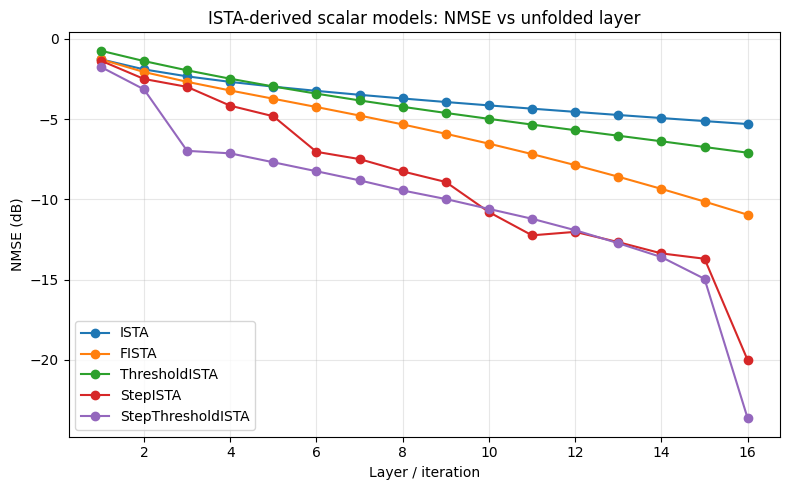

Saved figure to: ../results/notebook_03\figures\scalar_ista_variants_nmse_vs_layers.pdf


In [7]:
plt.figure(figsize=(8, 5))

for name in ["ISTA", "FISTA", "ThresholdISTA", "StepISTA", "StepThresholdISTA"]:
    plt.plot(
        range(1, K + 1),
        layer_curves[name],
        marker="o",
        label=name,
    )

plt.xlabel("Layer / iteration")
plt.ylabel("NMSE (dB)")
plt.title("ISTA-derived scalar models: NMSE vs unfolded layer")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "scalar_ista_variants_nmse_vs_layers.pdf")
plt.savefig(fig_path)
plt.show()

print(f"Saved figure to: {fig_path}")

## 2. LISTA Training-Method Comparison

We now compare different training methodologies for LISTA-style unfolded optimizers.

The architecture is fixed as LISTA, but the training procedure changes:

- **L1**: final-layer loss only.
- **L2**: final-layer loss with intermediate supervision.
- **L3**: greedy layer-wise training.

This directly addresses the instructor's request to compare training methods for unfolded optimizers.

### 2.1 LISTA-L1 — Final-Layer Loss Only

In [8]:
torch.manual_seed(SEED)

lista_l1 = LISTA(A, n_layers=K, tied=False, lam=LAM).to(device)

print("Training LISTA-L1")

t0 = time.time()

history = train(
    model=lista_l1,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=50,
    lr=1e-3,
    weight_decay=0.0,
    device=device,
    patience=20,
    intermediate_weight=0.0,
    verbose=True,
)

train_sec = time.time() - t0

histories["LISTA-L1"] = history

evaluate_and_store(
    name="LISTA-L1",
    model=lista_l1,
    training_type=f"L1 final loss ({train_sec / 60:.1f} min train)",
    save_checkpoint=True,
)

Training LISTA-L1


Training: 100%|██████████| 50/50 [05:36<00:00,  6.73s/epoch, lr=5.00e-04, train_loss=0.0029, val_nmse=-20.27 dB]


LISTA-L1                 NMSE= -20.338 dB | params=   6000016 | runtime=   6.466 ms


### 2.2 LISTA-L2 — Intermediate Supervision

L2 uses the same untied LISTA architecture as L1, but changes the training objective.

Instead of supervising only the final output, we also add losses on intermediate unfolded layers:

$$
\mathcal{L}
=
\|x-\hat{x}^{K}\|_2^2
+
\alpha \sum_{k=1}^{K-1} w_k \|x-\hat{x}^{k}\|_2^2
$$

This encourages each unfolded layer to produce a useful reconstruction, making the layerwise behavior more algorithmic and interpretable.

In [9]:
torch.manual_seed(SEED)

lista_l2 = LISTA(A, n_layers=K, tied=False, lam=LAM).to(device)

print("Training LISTA-L2")

t0 = time.time()

history = train(
    model=lista_l2,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=50,
    lr=1e-3,
    weight_decay=0.0,
    device=device,
    patience=20,
    intermediate_weight=0.1,
    verbose=True,
)

train_sec = time.time() - t0

histories["LISTA-L2"] = history

evaluate_and_store(
    name="LISTA-L2",
    model=lista_l2,
    training_type=f"L2 intermediate ({train_sec / 60:.1f} min train)",
    save_checkpoint=True,
)

Training LISTA-L2


Training: 100%|██████████| 50/50 [07:02<00:00,  8.45s/epoch, lr=1.00e-03, train_loss=0.0012, val_nmse=-21.06 dB]


LISTA-L2                 NMSE= -21.890 dB | params=   6000016 | runtime=   6.995 ms


### 2.3 LISTA-L3 — Greedy Layer-Wise Training

L3 trains the same untied LISTA architecture using greedy layer-wise training.

At stage \(k\), only layer \(k\) is trainable, while all previous layers are frozen.
The loss is evaluated at the output of the \(k+1\)-layer prefix:

$$
\mathcal{L}_k
=
\|x-\hat{x}^{k+1}\|_2^2
$$

This training method is more algorithmic: each unfolded layer is explicitly trained to improve the current estimate.

In [10]:
torch.manual_seed(SEED)

lista_l3 = LISTA(A, n_layers=K, tied=False, lam=LAM).to(device)

print("Training LISTA-L3")

t0 = time.time()

history = train_sequential(
    model=lista_l3,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs_per_layer=5,
    lr=1e-3,
    weight_decay=0.0,
    device=device,
    patience=5,
    verbose=True,
)

train_sec = time.time() - t0

histories["LISTA-L3"] = history

evaluate_and_store(
    name="LISTA-L3",
    model=lista_l3,
    training_type=f"L3 greedy ({train_sec / 60:.1f} min train)",
    save_checkpoint=True,
)

Training LISTA-L3


Layer 16/16: 100%|██████████| 5/5 [00:16<00:00,  3.25s/epoch, train_loss=0.0019, val_nmse=-16.53 dB]


LISTA-L3                 NMSE= -16.586 dB | params=   6000016 | runtime=   6.488 ms


### 2.4 LISTA-Tied-L1 — Shared Parameters

We now compare untied LISTA to tied LISTA.

In untied LISTA, each unfolded layer has its own parameters:

$$
\{W_y^k, W_x^k, \theta_k\}_{k=1}^{K}
$$

In tied LISTA, the same learned update rule is reused at every layer:

$$
W_y^1 = \cdots = W_y^K,\quad
W_x^1 = \cdots = W_x^K,\quad
\theta_1 = \cdots = \theta_K
$$

This greatly reduces the number of learned parameters and makes the model closer to an iterative algorithm.

In [11]:
torch.manual_seed(SEED)

lista_tied_l1 = LISTA(A, n_layers=K, tied=True, lam=LAM).to(device)

print("Training LISTA-Tied-L1")

t0 = time.time()

history = train(
    model=lista_tied_l1,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=50,
    lr=1e-3,
    weight_decay=0.0,
    device=device,
    patience=20,
    intermediate_weight=0.0,
    verbose=True,
)

train_sec = time.time() - t0

histories["LISTA-Tied-L1"] = history

evaluate_and_store(
    name="LISTA-Tied-L1",
    model=lista_tied_l1,
    training_type=f"tied L1 ({train_sec / 60:.1f} min train)",
    save_checkpoint=True,
)

Training LISTA-Tied-L1


Training: 100%|██████████| 50/50 [04:45<00:00,  5.71s/epoch, lr=1.00e-03, train_loss=0.0012, val_nmse=-18.46 dB]


LISTA-Tied-L1            NMSE= -19.126 dB | params=    375001 | runtime=   6.047 ms


### 2.5 LISTA-Tied-L2 — Shared Parameters with Intermediate Supervision

Finally, we combine tied LISTA with intermediate supervision.

This tests whether a single learned ISTA-like update rule can produce useful reconstructions at every unfolded layer when trained with layerwise losses.

In [12]:
torch.manual_seed(SEED)

lista_tied_l2 = LISTA(A, n_layers=K, tied=True, lam=LAM).to(device)

print("Training LISTA-Tied-L2")

t0 = time.time()

history = train(
    model=lista_tied_l2,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=50,
    lr=1e-3,
    weight_decay=0.0,
    device=device,
    patience=20,
    intermediate_weight=0.1,
    verbose=True,
)

train_sec = time.time() - t0

histories["LISTA-Tied-L2"] = history

evaluate_and_store(
    name="LISTA-Tied-L2",
    model=lista_tied_l2,
    training_type=f"tied L2 ({train_sec / 60:.1f} min train)",
    save_checkpoint=True,
)

Training LISTA-Tied-L2


Training: 100%|██████████| 50/50 [05:59<00:00,  7.20s/epoch, lr=1.00e-03, train_loss=0.0018, val_nmse=-19.02 dB]


LISTA-Tied-L2            NMSE= -19.013 dB | params=    375001 | runtime=   6.032 ms


## 3. ALISTA Reference — Analytic Correction Matrix

We now compare our `StepThresholdISTA` model to ALISTA.

Both models learn per-layer step sizes and thresholds, but they differ in the correction direction.

`StepThresholdISTA` uses the original ISTA correction:

$$
A^T(b-Ax^k)
$$

ALISTA replaces \(A^T\) with an analytic matrix \(W^T\):

$$
W^T(b-Ax^k)
$$

This comparison isolates the contribution of the analytic correction matrix.

In [13]:
torch.manual_seed(SEED)

alista = ALISTA(A, n_layers=K, W_iters=2000).to(device)

print("Training ALISTA")

t0 = time.time()

history = train(
    model=alista,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=50,
    lr=5e-4,
    weight_decay=1e-5,
    device=device,
    patience=15,
    intermediate_weight=0.0,
    verbose=True,
)

train_sec = time.time() - t0

histories["ALISTA"] = history

evaluate_and_store(
    name="ALISTA",
    model=alista,
    training_type=f"analytic W + scalars ({train_sec / 60:.1f} min train)",
    save_checkpoint=True,
)

Training ALISTA


Training: 100%|██████████| 50/50 [09:31<00:00, 11.43s/epoch, lr=5.00e-04, train_loss=0.0001, val_nmse=-29.75 dB]


ALISTA                   NMSE= -29.782 dB | params=        32 | runtime=  15.777 ms


## 4. HyperLISTA Reference — Hyperparameter-Adaptive Unfolding

HyperLISTA is included as an additional lightweight model-based reference.

Unlike LISTA or ALISTA, HyperLISTA does not learn layer-wise parameters by backpropagation. Instead, it uses only three global hyperparameters \((c_1,c_2,c_3)\), selected by validation grid search, to control adaptive thresholds, momentum, and support selection.

This provides another point in the model-based design space: very few learned/tuned quantities, but highly structured adaptive updates.

In [14]:
torch.manual_seed(SEED)

hyperlista = HyperLISTA(A, n_layers=K, W_iters=2000).to(device)

print("Tuning HyperLISTA")

t0 = time.time()

best_hparams = tune_hyperlista(
    model=hyperlista,
    val_loader=val_loader,
    device=device,
    coarse_points=5,
    fine_points=7,
    coarse_batches=4,
    fine_batches=8,
    verbose=True,
)

tune_sec = time.time() - t0

histories["HyperLISTA"] = best_hparams

with open(os.path.join(CKPT_DIR, "hyperlista_hparams.json"), "w") as f:
    json.dump(best_hparams, f, indent=2)

evaluate_and_store(
    name="HyperLISTA",
    model=hyperlista,
    training_type=f"grid-tuned hparams ({tune_sec / 60:.1f} min tune)",
    save_checkpoint=False,
)

print("Best HyperLISTA hyperparameters:")
print(best_hparams)

Tuning HyperLISTA
=== Stage 1: Coarse grid search ===


Coarse grid: 100%|██████████| 125/125 [00:17<00:00,  7.32it/s, best_nmse=-61.72 dB]


Coarse best: c1=0.0447, c2=0.0224, c3=3.8730  NMSE=-61.72 dB  (17.1s)

=== Stage 2: Fine grid search ===


Coarse grid: 100%|██████████| 343/343 [01:31<00:00,  3.74it/s, best_nmse=-61.05 dB]


Fine best:   c1=0.0447, c2=0.0224, c3=3.8730  NMSE=-61.05 dB  (91.7s)
HyperLISTA               NMSE= -61.386 dB | params=         3 | runtime=  36.005 ms
Best HyperLISTA hyperparameters:
{'c1': 0.044721359549995794, 'c2': 0.022360679774997897, 'c3': 3.8729833462074175, 'nmse_db': -61.0502827167511}


## 5. Final Summary

The table below summarizes all models in this notebook in terms of reconstruction quality, parameter count, runtime, and training method.

In [15]:
display_order = [
    "ISTA",
    "FISTA",
    "ThresholdISTA",
    "StepISTA",
    "StepThresholdISTA",
    "LISTA-L1",
    "LISTA-L2",
    "LISTA-L3",
    "LISTA-Tied-L1",
    "LISTA-Tied-L2",
    "ALISTA",
    "HyperLISTA",
]

print(f"{'Model':<24} {'NMSE (dB)':>12} {'# Params':>12} {'Runtime (ms)':>14} {'Training':>36}")
print("-" * 104)

for name in display_order:
    if name not in results:
        continue

    r = results[name]
    print(
        f"{name:<24} "
        f"{r['nmse_db']:>12.3f} "
        f"{r['n_params']:>12} "
        f"{r['runtime_ms']:>14.3f} "
        f"{r['training']:>36}"
    )

Model                       NMSE (dB)     # Params   Runtime (ms)                             Training
--------------------------------------------------------------------------------------------------------
ISTA                           -5.306            0          5.466                                 none
FISTA                         -10.959            0          6.630                                 none
ThresholdISTA                  -7.093           16          6.601                           final loss
StepISTA                      -20.025           16          7.125                           final loss
StepThresholdISTA             -23.648           32          7.119                           final loss
LISTA-L1                      -20.338      6000016          6.466        L1 final loss (5.6 min train)
LISTA-L2                      -21.890      6000016          6.995      L2 intermediate (7.0 min train)
LISTA-L3                      -16.586      6000016          6.488      

## 6. LISTA Training Methods: Layerwise NMSE

This plot compares the effect of different training methodologies on the same untied LISTA architecture.

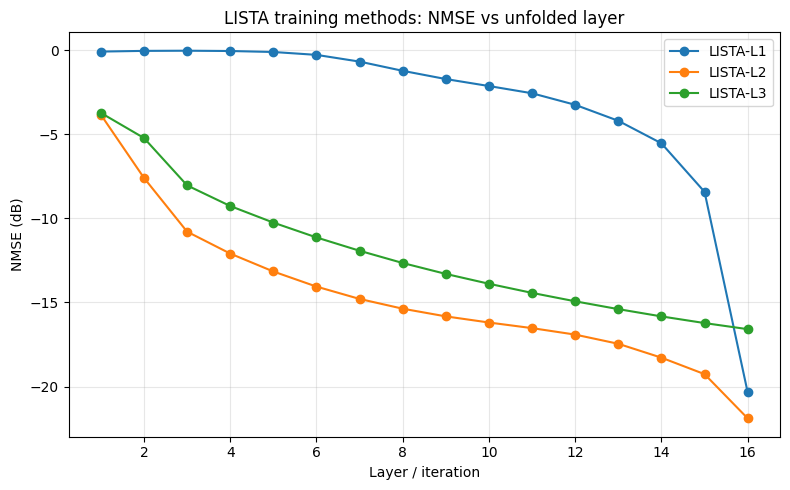

Saved figure to: ../results/notebook_03\figures\lista_training_methods_nmse_vs_layers.pdf


In [16]:
plt.figure(figsize=(8, 5))

for name in ["LISTA-L1", "LISTA-L2", "LISTA-L3"]:
    plt.plot(
        range(1, K + 1),
        layer_curves[name],
        marker="o",
        label=name,
    )

plt.xlabel("Layer / iteration")
plt.ylabel("NMSE (dB)")
plt.title("LISTA training methods: NMSE vs unfolded layer")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "lista_training_methods_nmse_vs_layers.pdf")
plt.savefig(fig_path)
plt.show()

print(f"Saved figure to: {fig_path}")

## 7. Accuracy–Model Size Tradeoff

This plot compares reconstruction quality against model size.

Because ISTA and FISTA have zero learned parameters, we visualize model size using:

$$
\log_{10}(\#\text{learned/tuned parameters}+1)
$$

The \(+1\) allows zero-parameter baselines to appear on the same logarithmic-style axis.

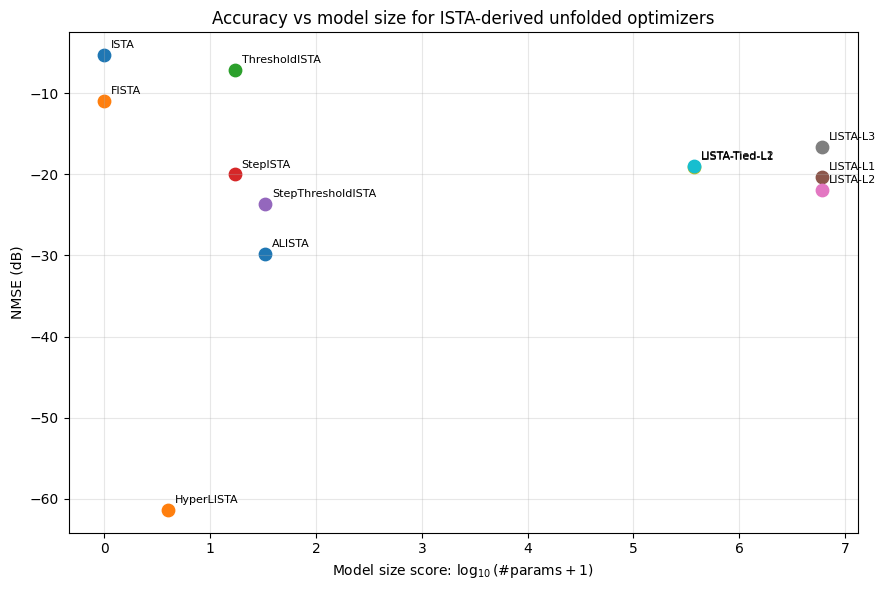

Saved figure to: ../results/notebook_03\figures\nmse_vs_model_size_tradeoff.pdf


In [17]:
plt.figure(figsize=(9, 6))

for name in display_order:
    if name not in results:
        continue

    r = results[name]
    model_size_score = np.log10(r["n_params"] + 1)
    nmse = r["nmse_db"]

    plt.scatter(model_size_score, nmse, s=80)
    plt.annotate(
        name,
        (model_size_score, nmse),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8,
    )

plt.xlabel(r"Model size score: $\log_{10}(\#\mathrm{params}+1)$")
plt.ylabel("NMSE (dB)")
plt.title("Accuracy vs model size for ISTA-derived unfolded optimizers")
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "nmse_vs_model_size_tradeoff.pdf")
plt.savefig(fig_path)
plt.show()

print(f"Saved figure to: {fig_path}")

## 8. Full Layerwise NMSE Curves

This plot compares the layerwise reconstruction behavior of all main models.

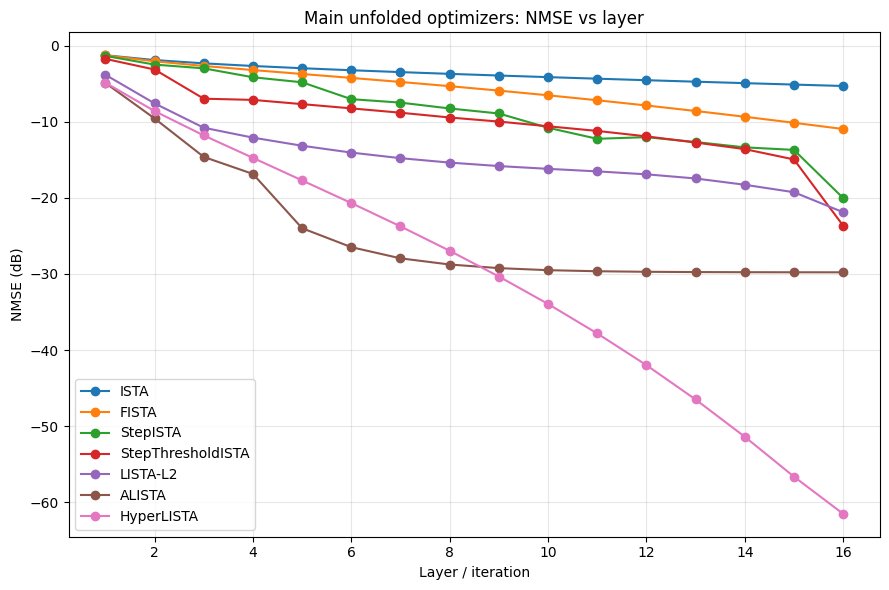

Saved figure to: ../results/notebook_03\figures\main_models_nmse_vs_layers.pdf


In [18]:
plot_order = [
    "ISTA",
    "FISTA",
    "StepISTA",
    "StepThresholdISTA",
    "LISTA-L2",
    "ALISTA",
    "HyperLISTA",
]

plt.figure(figsize=(9, 6))

for name in plot_order:
    if name not in layer_curves:
        continue

    plt.plot(
        range(1, K + 1),
        layer_curves[name],
        marker="o",
        label=name,
    )

plt.xlabel("Layer / iteration")
plt.ylabel("NMSE (dB)")
plt.title("Main unfolded optimizers: NMSE vs layer")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "main_models_nmse_vs_layers.pdf")
plt.savefig(fig_path)
plt.show()

print(f"Saved figure to: {fig_path}")